In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
input_folder = r"C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\tracked_frames\match1"
frame_files = sorted([f for f in os.listdir(input_folder) if f.endswith(".jpg")])

print("Total tracked frames:", len(frame_files))

Total tracked frames: 164


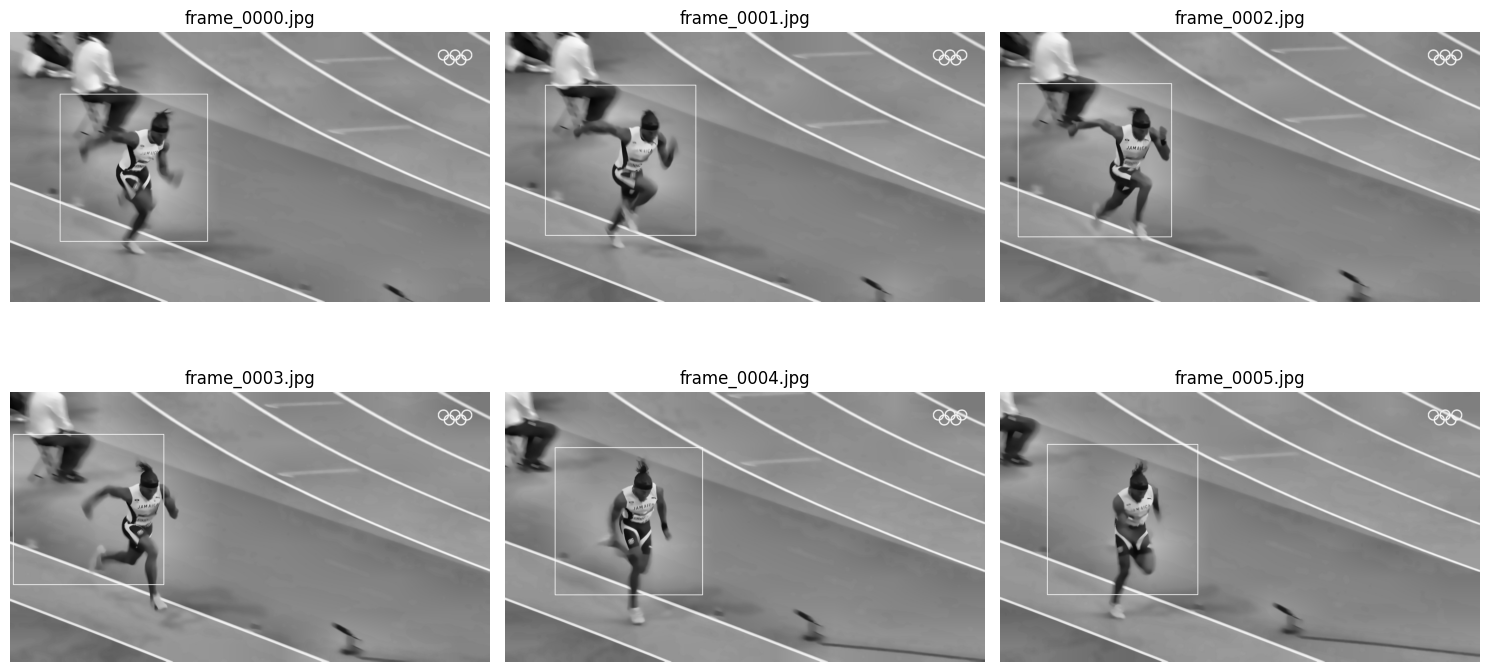

In [3]:
sample_files = frame_files[:6]

plt.figure(figsize=(15,8))

for i, file in enumerate(sample_files):
    img_path = os.path.join(input_folder, file)
    img = cv2.imread(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
tracking_points = []

for file in frame_files:
    img_path = os.path.join(input_folder, file)
    img = cv2.imread(img_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # detect white centroid marker drawn in notebook 08
    _, mask = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        largest = max(contours, key=cv2.contourArea)

        x, y, w, h = cv2.boundingRect(largest)

        cx = x + w // 2
        cy = y + h // 2

        tracking_points.append((cx, cy))
    else:
        tracking_points.append((None, None))

print("Tracking points reconstructed.")

Tracking points reconstructed.


In [6]:
print("First 10 tracking points:")

for i, point in enumerate(tracking_points[:10]):
    print(f"Frame {i}: {point}")

First 10 tracking points:
Frame 0: (495, 543)
Frame 1: (462, 513)
Frame 2: (379, 513)
Frame 3: (314, 470)
Frame 4: (495, 517)
Frame 5: (490, 510)
Frame 6: (481, 506)
Frame 7: (531, 530)
Frame 8: (548, 495)
Frame 9: (555, 522)


In [7]:
valid_points = [p for p in tracking_points if p[0] is not None and p[1] is not None]

print("Valid tracking points:", len(valid_points))
print("Missing tracking points:", len(tracking_points) - len(valid_points))

Valid tracking points: 164
Missing tracking points: 0


In [13]:
stability_threshold = 50

stable_transitions = sum(d < stability_threshold for d in displacements)
unstable_transitions = sum(d >= stability_threshold for d in displacements)

print("Stable transitions:", stable_transitions)
print("Unstable transitions:", unstable_transitions)

if len(displacements) > 0:
    stability_percentage = (stable_transitions / len(displacements)) * 100
    print("Tracking stability percentage:", round(stability_percentage, 2), "%")

Stable transitions: 134
Unstable transitions: 29
Tracking stability percentage: 82.21 %


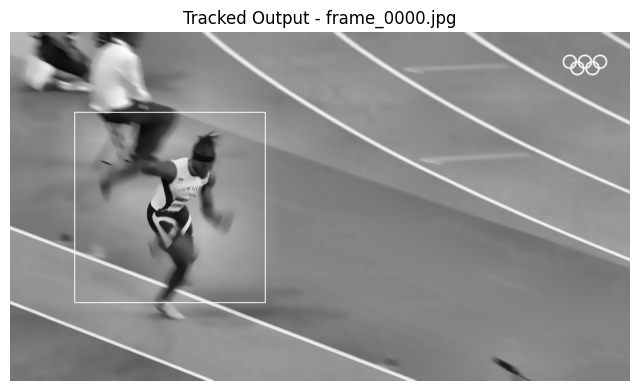

In [15]:
frame_name = frame_files[0]

tracked_img = cv2.imread(os.path.join(input_folder, frame_name))

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(tracked_img, cv2.COLOR_BGR2RGB))
plt.title(f"Tracked Output - {frame_name}")
plt.axis("off")
plt.show()